### Importing necessary libraries

In [1]:
from pathlib import Path
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

### Reproducibility

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Data Path

In [3]:
DATA_ROOT = Path("../../dataset").resolve()

MONET_DIR = DATA_ROOT / "monet_jpg"
PHOTO_DIR = DATA_ROOT / "photo_jpg"

print("Data root:", DATA_ROOT)
print("Monet folder exists:", MONET_DIR.exists())
print("Photo folder exists:", PHOTO_DIR.exists())

Data root: C:\Users\samruddhi\Downloads\DATA266-Lab1-Pair45\task3_GAN\dataset
Monet folder exists: True
Photo folder exists: True


### Define image transformations

In [4]:
IMAGE_SIZE = 256
RESIZE_SIZE = 286

train_transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.RandomCrop((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

### Create the unpaired dataset

In [5]:
class UnpairedImageDataset(Dataset):
    def __init__(self, domain_a_dir, domain_b_dir, transform=None):
        self.domain_a_dir = Path(domain_a_dir)
        self.domain_b_dir = Path(domain_b_dir)
        self.transform = transform

        valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

        self.domain_a_images = sorted([
            path for path in self.domain_a_dir.iterdir()
            if path.suffix.lower() in valid_extensions
        ])

        self.domain_b_images = sorted([
            path for path in self.domain_b_dir.iterdir()
            if path.suffix.lower() in valid_extensions
        ])

        if len(self.domain_a_images) == 0:
            raise ValueError(f"No images found in {self.domain_a_dir}")

        if len(self.domain_b_images) == 0:
            raise ValueError(f"No images found in {self.domain_b_dir}")

    def __len__(self):
        # Use the larger domain size so all images can be sampled
        return max(len(self.domain_a_images), len(self.domain_b_images))

    def __getitem__(self, index):
        # Domain A image
        image_a_path = self.domain_a_images[index % len(self.domain_a_images)]

        # Randomly select a separate Domain B image
        image_b_path = random.choice(self.domain_b_images)

        image_a = Image.open(image_a_path).convert("RGB")
        image_b = Image.open(image_b_path).convert("RGB")

        if self.transform is not None:
            image_a = self.transform(image_a)
            image_b = self.transform(image_b)

        return {
            "A": image_a,
            "B": image_b,
            "A_path": str(image_a_path),
            "B_path": str(image_b_path)
        }

### Create the dataset and DataLoader

In [6]:
dataset = UnpairedImageDataset(
    domain_a_dir=PHOTO_DIR,
    domain_b_dir=MONET_DIR,
    transform=train_transform
)

BATCH_SIZE = 10

train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Number of photo images:", len(dataset.domain_a_images))
print("Number of Monet images:", len(dataset.domain_b_images))
print("Number of training samples:", len(dataset))

Number of photo images: 7038
Number of Monet images: 300
Number of training samples: 7038


In [7]:
batch = next(iter(train_loader))

print("Photo batch shape:", batch["A"].shape)
print("Monet batch shape:", batch["B"].shape)
print("Photo path:", batch["A_path"][0])
print("Monet path:", batch["B_path"][0])

Photo batch shape: torch.Size([10, 3, 256, 256])
Monet batch shape: torch.Size([10, 3, 256, 256])
Photo path: C:\Users\samruddhi\Downloads\DATA266-Lab1-Pair45\task3_GAN\dataset\photo_jpg\cb706347dd.jpg
Monet path: C:\Users\samruddhi\Downloads\DATA266-Lab1-Pair45\task3_GAN\dataset\monet_jpg\32cc820303.jpg


### Visually verify the transformed images

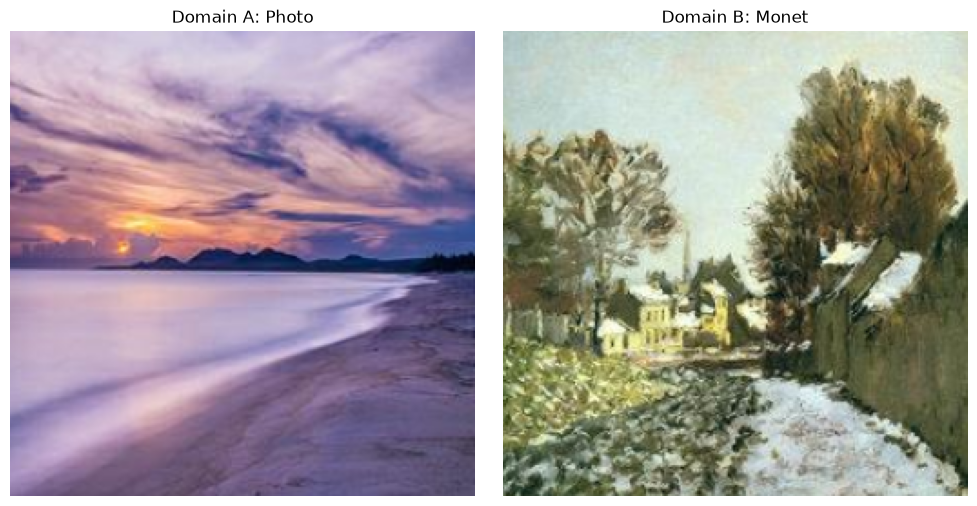

In [8]:
import matplotlib.pyplot as plt

def denormalize(image_tensor):
    """
    Convert image values from [-1, 1] back to [0, 1]
    for displaying.
    """
    image_tensor = image_tensor * 0.5 + 0.5
    return image_tensor.clamp(0, 1)


photo_image = denormalize(batch["A"][0])
monet_image = denormalize(batch["B"][0])

photo_image = photo_image.permute(1, 2, 0).numpy()
monet_image = monet_image.permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(photo_image)
axes[0].set_title("Domain A: Photo")
axes[0].axis("off")

axes[1].imshow(monet_image)
axes[1].set_title("Domain B: Monet")
axes[1].axis("off")

plt.tight_layout()
plt.show()

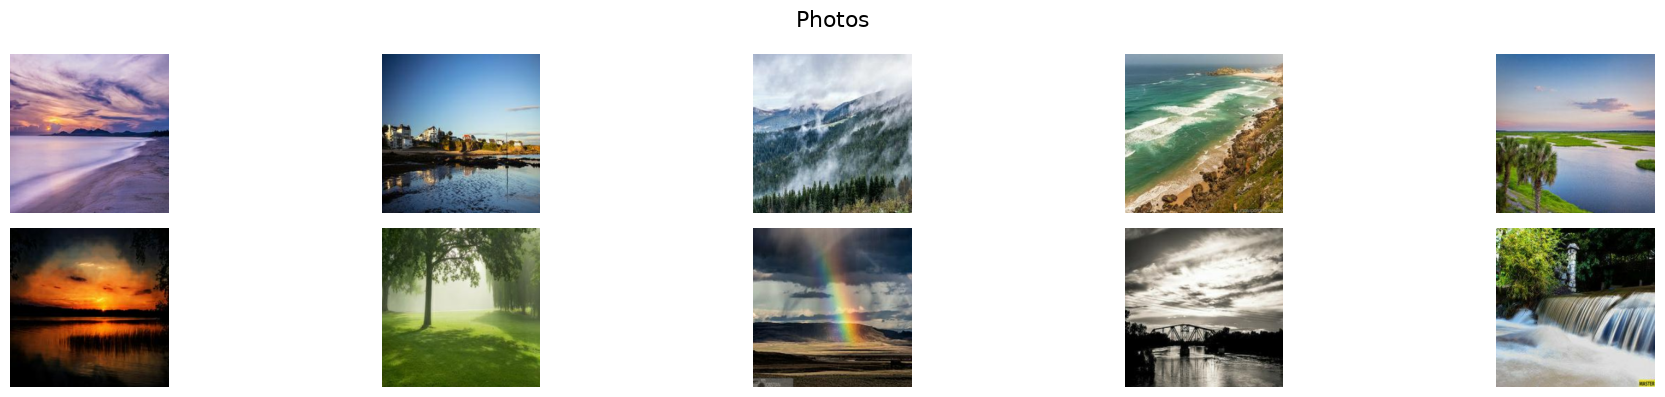

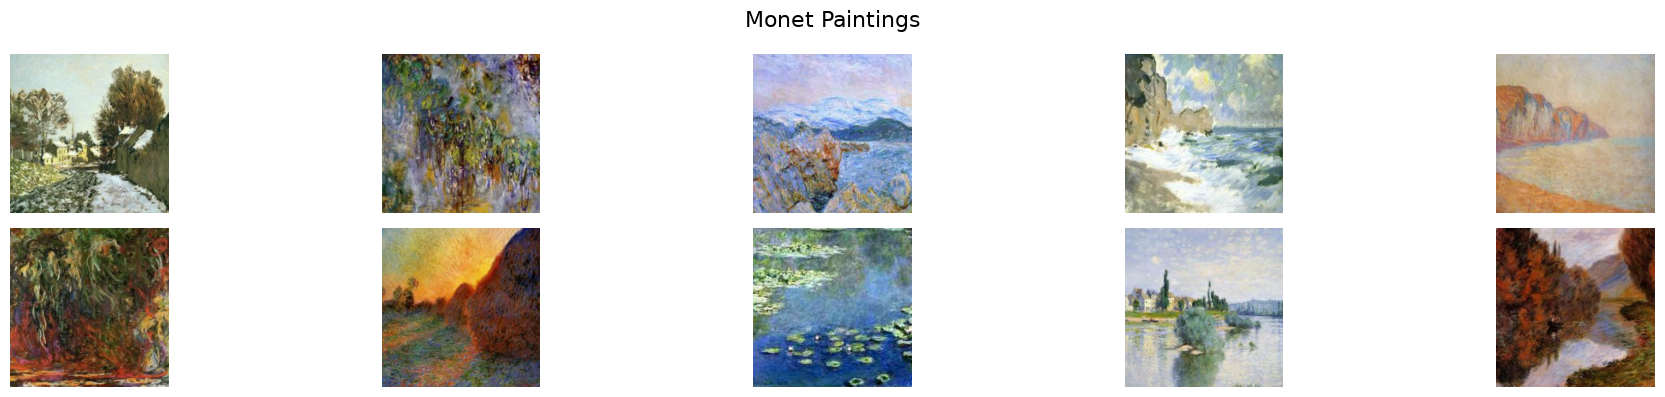

In [9]:
def show_images(images, title, n=10):
    plt.figure(figsize=(20, 4))

    for i in range(n):
        image = denormalize(images[i])
        image = image.permute(1, 2, 0).numpy()

        plt.subplot(2, 5, i + 1)
        plt.imshow(image)
        plt.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


show_images(batch["A"], "Photos", n=10)
show_images(batch["B"], "Monet Paintings", n=10)


In [10]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4090
